# Dataset audit

What is actually in the Watkins full cuts release, and what survives the common-band filter.

Nothing is trained here. Run `python -m src.data.manifest --config configs/base.yaml` first.

In [1]:
import sys
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

sys.path.insert(0, str(Path.cwd().parent))
from src.config import load_config

cfg = load_config("configs/base.yaml")
META = cfg.paths.metadata
REPORT = cfg.paths.reports / cfg.name
pd.set_option("display.width", 160)

## Coverage

`clips` and `tapes` are what the archive holds. `kept_*` is what remains after dropping files
recorded below the target rate and clips shorter than the window minimum.

In [2]:
coverage = pd.read_csv(META / f"audit_coverage_{cfg.name}.csv")
coverage

,species,clips,tapes,kept_clips,kept_tapes,kept_hours
0,HumpbackWhale,604,14,546,12,1.954924
1,KillerWhale,2647,65,2601,65,1.649322
2,SpermWhale,1379,63,1013,58,12.230502


In [3]:
dropped = pd.read_csv(META / f"audit_dropped_{cfg.name}.csv")
dropped

,species,drop_reason,clips,tapes
0,HumpbackWhale,clip_too_short,1,1
1,HumpbackWhale,native_rate_below_target,57,3
2,KillerWhale,clip_too_short,46,15
3,SpermWhale,clip_too_short,366,19


## Sample rate is close to a species label

This is the finding that shapes the whole project. Species were recorded on different equipment
across five decades, so native sample rate separates them before any audio is examined. Everything
kept is resampled to a single rate, giving every file the same usable band.

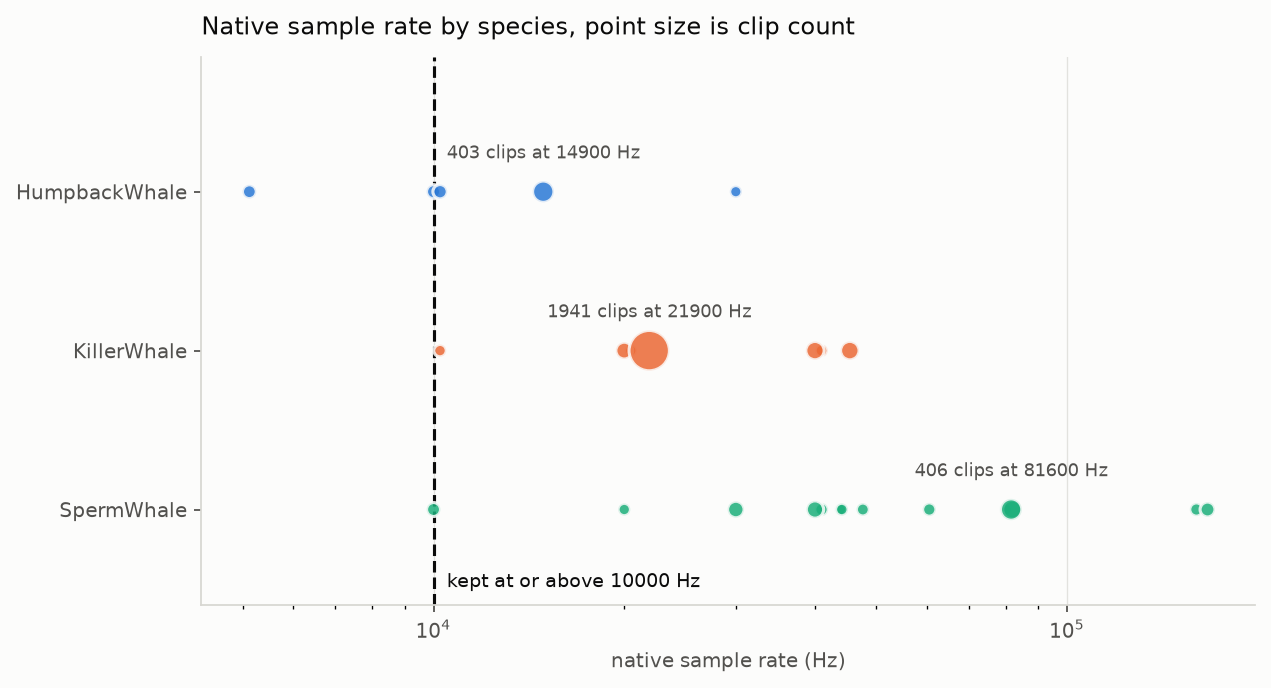

native_sample_rate,5120,10000,10240,14900,20000,20480,21900,30000,40000,40960,43900,44100,45400,47600,60600,80000,81600,81920,160000,166600
species,,,,,,,,,,,,,,,,,,,,
HumpbackWhale,57.0,66.0,76.0,403.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
KillerWhale,0.0,0.0,7.0,0.0,177.0,4.0,1941.0,0.0,246.0,18.0,0.0,0.0,254.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
SpermWhale,0.0,62.0,0.0,0.0,6.0,0.0,0.0,162.0,199.0,40.0,2.0,10.0,0.0,24.0,38.0,22.0,406.0,274.0,37.0,97.0


In [4]:
from src.evaluate import plots

rates = pd.read_csv(META / f"audit_sample_rates_{cfg.name}.csv")
figure = plots.sample_rate_profile(
    rates, REPORT / "sample_rates.png", cfg.audio.target_sample_rate
)
display(Image(filename=str(figure)))
rates.pivot_table(index="species", columns="native_sample_rate", values="clips", fill_value=0)

## Clips overstate the data

Cuts from one tape are near duplicates of each other. Tape count, not clip count, is the size of
this dataset, and it is the unit the folds are built over.

In [5]:
per_tape = pd.read_csv(META / f"audit_per_tape_{cfg.name}.csv")
kept = per_tape[per_tape.kept_clips > 0]
kept.groupby("species").agg(
    tapes=("tape_id", "nunique"),
    clips=("kept_clips", "sum"),
    hours=("seconds", lambda s: round(s.sum() / 3600, 2)),
)

,tapes,clips,hours
species,,,
HumpbackWhale,12,546,1.97
KillerWhale,65,2601,1.65
SpermWhale,58,1013,12.25


In [6]:
kept.nlargest(10, "kept_clips")[["species", "tape_id", "year", "native_sample_rate", "kept_clips", "seconds"]]

,species,tape_id,year,native_sample_rate,kept_clips,seconds
15,KillerWhale,60026,1960,40960,272,823.877805
12,HumpbackWhale,86008,1986,14900,254,962.290738
21,KillerWhale,64031,1964,40000,178,439.169200
29,KillerWhale,92304,1992,21900,173,366.452420
33,KillerWhale,97504,1997,21900,143,342.220046
24,KillerWhale,89405,1989,21900,140,220.203288
25,KillerWhale,92300,1992,21900,138,567.150913
27,KillerWhale,92302,1992,21900,103,613.820183
101,SpermWhale,85002,1985,81920,95,452.895104
110,SpermWhale,88002,1988,81600,95,857.014646


## Tapes carrying more than one species

Grouping is applied across species rather than within, so a tape cut into clips of two species
still lands entirely on one side of every fold boundary.

In [7]:
shared = pd.read_csv(META / f"audit_cross_species_tapes_{cfg.name}.csv")
targets = set(cfg.dataset.species)
shared[shared.species.apply(lambda s: len(targets & {p.strip() for p in s.split(",")}) > 1)]

,tape_id,n_species,species
0,52008,2,"HumpbackWhale, SpermWhale"
